<a href="https://colab.research.google.com/github/kitlapp/NLP-Course/blob/main/pr_02_feature_engineering_embeddings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Section 2 - Feature Engineering: Text Embeddings
This notebook focuses on the feature engineering stage of the NLP pipeline. The objective is to transform preprocessed drug reviews into numerical text representations using two embedding techniques:

- TF-IDF
- Word2Vec

In [ ]:
!find /content -name "tfidf_matrix.npz" -o -name "tfidf_vectorizer.joblib" -o -name "word2vec_model.model"

/content/tfidf_vectorizer.joblib
/content/word2vec_model.model
/content/tfidf_matrix.npz
/content/drive/.shortcut-targets-by-id/1spDsOxCQ2BARxbTrWTqTPRZEXoxvlDtl/nlp_project_data/tfidf_matrix.npz
/content/drive/.shortcut-targets-by-id/1spDsOxCQ2BARxbTrWTqTPRZEXoxvlDtl/nlp_project_data/tfidf_vectorizer.joblib
/content/drive/.shortcut-targets-by-id/1spDsOxCQ2BARxbTrWTqTPRZEXoxvlDtl/nlp_project_data/word2vec_model.model
find: ‘/content/drive/.Encrypted/.shortcut-targets-by-id/1spDsOxCQ2BARxbTrWTqTPRZEXoxvlDtl/nlp_project_data’: No such file or directory


# 0. Import Libraries and Setup Configurations

Gensim module should be installed before being imported as a library at the cell below. This module is a NLP library that provides implementations of unsupervised learning algorithms, such as Word2Vec, TF-IDF, and Latent Dirichlet Allocation (LDA).

In [ ]:
!pip install gensim

In [ ]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt

# Feature engineering
from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.models import Word2Vec

# Dimensionality reduction
from sklearn.manifold import TSNE

# pathlib provides a cleaner and safer way to handle file paths.
# It automatically handles path joining and improves compatibility
# across different environments.
from pathlib import Path

# Save TF-IDF matrix and vectorizer
import joblib
from scipy import sparse

import shutil

pd.set_option('display.max_colwidth', None)

# 1. Load the Cleaned Datasets from pr_01_data_collection_and_preprocessing.ipynb

The preprocessing stage of the NLP pipeline was completed in "pr_01_data_collection_and_preprocessing" notebook. Two preprocessed datasets are used in this notebook:

- **`df_lem_final.parquet`** – contains lemmatized reviews and is used for TF-IDF feature extraction, as lemmatization reduces vocabulary size and improves statistical text representation.
- **`df_non_lem_final.parquet`** – contains non-lemmatized reviews together with tokenized text and is used for Word2Vec, allowing the model to learn semantic relationships from natural language.

Using separate datasets enables each embedding technique to operate on the text representation that best suits its methodology.

## 1.1. Mount Google Drive

Google Colab authenticates Google Drive using the same Google account that is running the Colab notebook. If you try to authenticate with another Google Drive account, there can be many bugs and troubleshooting problems. The Colab session is secure and isolated from other Google Drive accounts, so it cannot directly access files from other accounts unless the account has access through sharing.

For example, an "x" email account that opens the notebook in Google Colab should ideally authenticate the session with the same "x" email account in Google Drive.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


The cell above just authenticates this session between Google Colab and Google Drive.

## 1.2. Handle Paths

As a next step, and to run this notebook without errors, the shared dataset folder should be available inside the Google Drive root directory, i.e., My Drive. If the shared data folder cannot be seen in the Google Drive root, find it under the "Shared with me" section, right-click it → Organize → Add shortcut → All locations → My Drive → Add.

Then, uncomment the above cell code and run it to confirm that the nlp_project_data folder is visible in My Drive.

In [ ]:
# !ls /content/drive/MyDrive

In [ ]:
# Path to root shared data folder (should work for every user after adding the shortcut)
ROOT_DATA_DIR = Path("/content/drive/MyDrive/nlp_project_data")

# Check that the folder exists
if ROOT_DATA_DIR.exists():
    print(f"Shared dataset folder found: {ROOT_DATA_DIR}")
else:
    raise FileNotFoundError(
        f"Dataset folder not found: {ROOT_DATA_DIR}\n"
        "Read the README instructions or the text cells in the sections "
        "'Mount Google Drive' and 'Handle Paths'.\n"
        "Ensure that the shared dataset folder has been added as a shortcut "
        "inside your My Drive, then rerun this cell."
    )

Shared dataset folder found: /content/drive/MyDrive/nlp_project_data


Assuming that this point has reached after a successful execution of the above cell, the things become very easy and managed. The only step left behind is the exact paths to the cleaned datasets, which act as inputs of this notebook.

In [ ]:
# Exact paths to the cleaned datasets
LEM_FILEPATH = ROOT_DATA_DIR / "df_lem_final.parquet"
NONLEM_FILEPATH = ROOT_DATA_DIR / "df_non_lem_final.parquet"

# Lemmatized dataset (for TF-IDF)
df_lem = pd.read_parquet(LEM_FILEPATH)

# Non-lemmatized dataset (for Word2Vec)
df_nonlem = pd.read_parquet(NONLEM_FILEPATH)

# 2. Exploring datasets

In [ ]:
print("Lemmatized dataset:", df_lem.shape)
print("Non-lemmatized dataset:", df_nonlem.shape)

Lemmatized dataset: (319934, 14)
Non-lemmatized dataset: (319934, 14)


In [ ]:
df_nonlem.head()

,Age,Condition,Date,Drug,DrugId,EaseofUse,Effectiveness,Reviews,Satisfaction,Sex,Sides,UsefulCount,tokens,Scores_Avg
0,75 or over,Stuffy Nose,9/21/2014,25dph-7.5peh,146724,5,5,retired physician meds tried allergies seasonal not one effective me. first began using drug years ago tiredness problem not currently.,5,Male,"Drowsiness, dizziness , dry mouth /nose/throat, headache , upset stomach , constipation , or trouble sleeping may occur.",0,"[retired, physician, meds, tried, allergies, seasonal, not, one, effective, me, ., first, began, using, drug, years, ago, tiredness, problem, not, currently, .]",5.00
1,25-34,Cold Symptoms,1/13/2011,25dph-7.5peh,146724,5,5,cleared right even throat hurting went away taking medicine,5,Female,"Drowsiness, dizziness , dry mouth /nose/throat, headache , upset stomach , constipation , or trouble sleeping may occur.",1,"[cleared, right, even, throat, hurting, went, away, taking, medicine]",5.00
2,65-74,Other,7/16/2012,warfarin (bulk) 100 % powder,144731,2,3,ptinr normal,3,Female,,0,"[ptinr, normal]",2.67
3,75 or over,Other,9/23/2010,warfarin (bulk) 100 % powder,144731,2,2,falling dont realise,1,Female,,0,"[falling, dont, realise]",1.67
4,35-44,Other,1/6/2009,warfarin (bulk) 100 % powder,144731,1,1,grandfather prescribed medication coumadin assist blood thinning due heart thyroid condition. primary doctor aware aspirin regiment still prescribed medicine caused blood thin much ended internally bleeding death. going take medicine please ask doctors possible side effects drug interactions.,1,Male,,1,"[grandfather, prescribed, medication, coumadin, assist, blood, thinning, due, heart, thyroid, condition, ., primary, doctor, aware, aspirin, regiment, still, prescribed, medicine, caused, blood, thin, much, ended, internally, bleeding, death, ., going, take, medicine, please, ask, doctors, possible, side, effects, drug, interactions, .]",1.00


In [ ]:
type(df_nonlem["tokens"].iloc[0])

numpy.ndarray

In [ ]:
df_nonlem["tokens"].iloc[0][:15]

array(['retired', 'physician', 'meds', 'tried', 'allergies', 'seasonal',
       'not', 'one', 'effective', 'me', '.', 'first', 'began', 'using',
       'drug'], dtype=object)

# 3. TF-IDF Embeddings


The first embedding technique explored is **TF-IDF**, the method that converts textual data into numerical feature vectors.

For this experiment, the **lemmatized dataset** is used because lemmatization groups different grammatical forms of the same word into a common base form, reducing vocabulary size and improving the quality of statistical text representations.

In [ ]:
# Extract the lemmatized reviews
reviews_lem = df_lem["Reviews"].dropna().astype(str)

print(f"Number of reviews available for TF-IDF: {len(reviews_lem):,}")

Number of reviews available for TF-IDF: 319,934


## 3.1. TF-IDF Vectorization

The TF-IDF vectorizer transforms each review into a numerical vector.

To improve efficiency and reduce noise:

- the vocabulary is limited to the **5,000 most informative terms**;
- words appearing in fewer than **5 documents** are removed;
- words appearing in more than **80% of documents** are ignored because they provide little discriminative information.

In [ ]:
tfidf = TfidfVectorizer(
    max_features=5000,
    min_df=5,
    max_df=0.8
)

tfidf_matrix = tfidf.fit_transform(reviews_lem)

print("TF-IDF matrix shape:", tfidf_matrix.shape)
print("Vocabulary size:", len(tfidf.get_feature_names_out()))

TF-IDF matrix shape: (319934, 5000)
Vocabulary size: 5000


In [ ]:
feature_names = tfidf.get_feature_names_out()

print(feature_names[:30])

['abate' 'abdomen' 'abdominal' 'abilify' 'ability' 'ablation' 'able'
 'abnormal' 'abnormally' 'about' 'above' 'abreva' 'abruptly' 'abscess'
 'absence' 'absolute' 'absolutely' 'absolutly' 'absorb' 'absorption' 'abt'
 'abuse' 'abused' 'abuser' 'accept' 'acceptable' 'access' 'accident'
 'accidentally' 'accompany']


## 3.2. Results

The resulting TF-IDF matrix contains one row for each review and one column for each vocabulary term.

The final representation consists of **319,934 reviews** and a vocabulary of **5,000 informative terms**, providing a sparse numerical representation suitable for traditional machine learning algorithms.

## 3.3. Inspecting a Sample Review

To better understand how TF-IDF represents text, a sample review is examined together with its highest-weighted terms.

The displayed words are those considered most informative for the selected review. Higher TF-IDF scores indicate that a term is particularly important within that review while being relatively uncommon across the overall corpus.

In [ ]:
# Select a sample review for inspection
doc_index = 0

print("Sample Review:\n")
print(reviews_lem.iloc[doc_index])

# Extract TF-IDF scores for the selected review
tfidf_scores = tfidf_matrix[doc_index].toarray().flatten()

# Identify the 10 most important terms
top_indices = tfidf_scores.argsort()[-10:][::-1]

print("\nTop 10 TF-IDF Terms:\n")

for idx in top_indices:
    print(f"{feature_names[idx]:<20} {tfidf_scores[idx]:.4f}")

Sample Review:

retired physician med try allergy seasonal not one effective me. first begin use drug year ago tiredness problem not currently.

Top 10 TF-IDF Terms:

seasonal             0.4111
tiredness            0.3242
physician            0.3208
allergy              0.3043
currently            0.3028
begin                0.2255
not                  0.2243
effective            0.2221
ago                  0.2011
problem              0.1837


# 4. Word2Vec Embeddings

## 4.1. Preparing the Input Data

Word2Vec requires each document to be represented as a sequence of tokens. Since the preprocessing stage already generated tokenized reviews, no additional tokenization was required.

The existing token arrays are converted into standard Python lists, providing the format expected by the Word2Vec implementation while preserving the original preprocessing performed during the previous stage of the project.

In [ ]:
# Preparing the tokenized reviews for Word2Vec training
# Punctuation tokens are removed to focus the model on meaningful words.
sentences = df_nonlem["tokens"].apply(
    lambda x: [token for token in x.tolist() if token.isalpha()]
).tolist()

## 4.2 Training the Word2Vec Model

The Word2Vec model is trained using the **Skip-gram** architecture, which learns vector representations by predicting surrounding words from a target word. Skip-gram is particularly effective for learning semantic relationships, especially in large text corpora.

The following parameters were selected:

- **`vector_size=100`**: Each word is represented by a 100-dimensional dense vector, providing a balance between expressive power and computational efficiency.
- **`window=5`**: Considers five words before and after the target word, allowing the model to capture meaningful contextual information.
- **`min_count=5`**: Removes very rare words that may correspond to typographical errors or noisy observations.
- **`sg=1`**: Uses the Skip-gram architecture instead of CBOW, improving semantic similarity learning.
- **`epochs=5`**: Trains the model over five iterations of the corpus, allowing the embeddings to converge while maintaining reasonable training time.

In [ ]:
# Train the Word2Vec model
w2v_model = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=5,
    workers=4,
    sg=1,
    epochs=5
)

print(f"Vocabulary size: {len(w2v_model.wv):,}")
print(f"Embedding dimension: {w2v_model.vector_size}")

Vocabulary size: 29,419
Embedding dimension: 100


## 4.3. Results

The trained model learned vector representations for **29,419 unique words**. Each word is represented by a **100-dimensional embedding**, enabling semantic similarity analysis and visualization of relationships between medical concepts.
The Gensim implementation of Word2Vec was used because it provides an efficient and widely adopted framework for learning distributed word representations."

## 4.4 Semantic Similarity Analysis

One of the main advantages of Word2Vec is its ability to capture semantic relationships between words.

Using the learned embeddings, the model can identify words that frequently occur in similar contexts. This provides insight into the semantic structure of the corpus and demonstrates that the model has successfully learned meaningful representations from the drug reviews.

In [ ]:
def show_similar_words(word, topn=10):
    """
    Display the most semantically similar words for a given query term.
    """

    print("=" * 60)
    print(f"Query word: '{word}'\n")

    if word in w2v_model.wv:
        similar_words = w2v_model.wv.most_similar(word, topn=topn)

        print(f"{'Similar Word':<20}{'Similarity Score'}")
        print("-" * 40)

        for similar_word, score in similar_words:
            print(f"{similar_word:<20}{score:.4f}")

    else:
        print(f"'{word}' was not found in the vocabulary.")

In [ ]:
example_words = [
    "pain",
    "headache",
    "sleep",
    "nausea",
    "doctor",
    "effective"
]

for word in example_words:
    show_similar_words(word)

Query word: 'pain'

Similar Word        Similarity Score
----------------------------------------
painswelling        0.7391
painespecially      0.7352
painand             0.7269
spasmspain          0.7254
pains               0.7247
arthritus           0.7188
tendernesspain      0.7092
painleg             0.7065
pian                0.7062
headneckear         0.7048
Query word: 'headache'

Similar Word        Similarity Score
----------------------------------------
headaches           0.8436
migrane             0.7699
neausea             0.7697
headach             0.7689
headace             0.7577
nausea              0.7521
migrainelike        0.7492
migraine            0.7474
throbbing           0.7355
dizziness           0.7311
Query word: 'sleep'

Similar Word        Similarity Score
----------------------------------------
restful             0.7980
sllep               0.7808
sleeping            0.7792
restfully           0.7552
uninterupted        0.7432
nights              0.7404

The retrieved words demonstrate that the Word2Vec model successfully captured contextual relationships within the corpus.

For example, medical symptoms such as *pain* and *headache* are associated with related clinical terms, while treatment-related words retrieve medication and healthcare concepts. These results indicate that words occurring in similar contexts have been mapped to nearby locations in the embedding space, validating the quality of the learned representations.

# 5. Word Embedding Visualization using t-SNE

Word2Vec embeddings are high-dimensional vectors, which makes them difficult to interpret visually. To explore the learned embedding space, t-SNE is used to project selected word vectors into two dimensions.

Instead of plotting a large number of random words, a curated set of medically meaningful terms is used. This improves interpretability and allows clearer comparison between symptom-related and treatment-related concepts.

In [ ]:
word_groups = {
    "Pain / Headache": ["pain", "headache", "migraine", "cramps", "ache"],
    "Digestive Symptoms": ["nausea", "vomiting", "diarrhea", "constipation", "stomach"],
    "Sleep / Fatigue": ["sleep", "sleeping", "insomnia", "tired", "fatigue"],
    "Skin Reactions": ["rash", "itching", "acne", "swelling"],
    "Treatment": ["doctor", "medicine", "drug", "dose", "treatment", "relief", "effective"]
}

words = []
labels = []

for group, group_words in word_groups.items():
    for word in group_words:
        if word in w2v_model.wv:
            words.append(word)
            labels.append(group)

vectors = np.array([w2v_model.wv[word] for word in words])

In [ ]:
tsne = TSNE(
    n_components=2,
    perplexity=5,
    random_state=42,
    init="pca",
    learning_rate="auto"
)

vectors_2d = tsne.fit_transform(vectors)

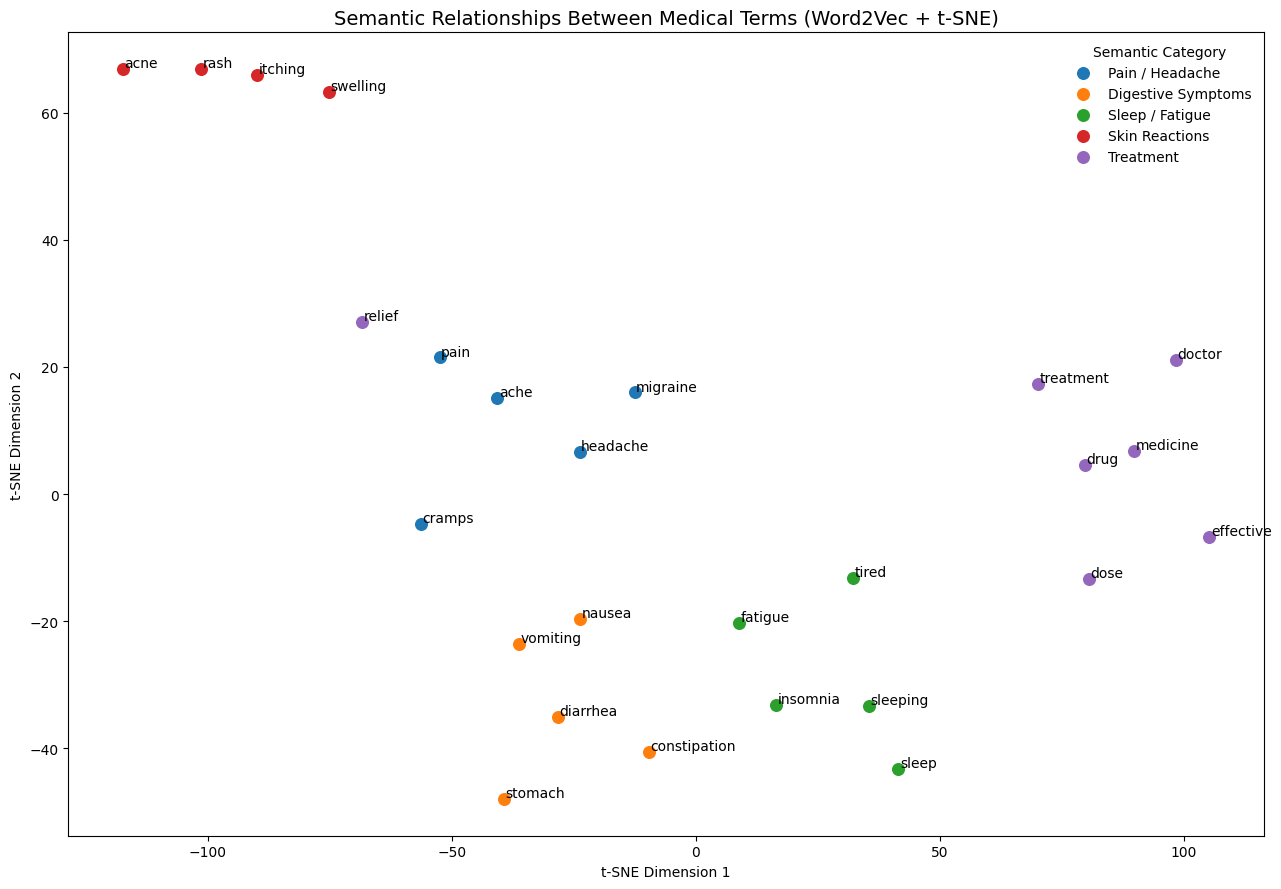

In [ ]:
plt.figure(figsize=(13, 9))

for group in word_groups.keys():
    indices = [i for i, label in enumerate(labels) if label == group]

    plt.scatter(
        vectors_2d[indices, 0],
        vectors_2d[indices, 1],
        s=70,
        label=group
    )

    for i in indices:
        plt.text(
            vectors_2d[i, 0] + 0.3,
            vectors_2d[i, 1] + 0.3,
            words[i],
            fontsize=10
        )

plt.title("Semantic Relationships Between Medical Terms (Word2Vec + t-SNE)", fontsize=14)
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.legend(title="Semantic Category", frameon=False)
plt.tight_layout()
plt.show()

The t-SNE projection provides a two-dimensional representation of the high-dimensional Word2Vec embedding space. Although exact distances should not be interpreted quantitatively, nearby words generally share similar semantic contexts.

The visualization indicates that words describing related medical concepts tend to occupy similar regions. For example, pain-related terms (e.g., *pain*, *headache*, *migraine*, and *ache*) are positioned relatively close to one another, while digestive symptoms (*nausea*, *vomiting*, *diarrhea*, and *constipation*) form another semantic neighborhood. Sleep-related terms also appear in a common region, suggesting that the model successfully learned contextual relationships from the drug review corpus.

Overall, the visualization supports the effectiveness of Word2Vec in capturing semantic similarity beyond simple word frequency.

# 6. Principal Component Analysis (PCA)

In addition to t-SNE, Principal Component Analysis (PCA) was applied to the Word2Vec embeddings. Unlike t-SNE, which focuses on preserving local neighborhoods, PCA is a linear dimensionality reduction technique that preserves the maximum amount of variance in the data. Comparing the two visualizations will provide complementary perspectives on the learned embedding space.

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)

vectors_pca = pca.fit_transform(vectors)

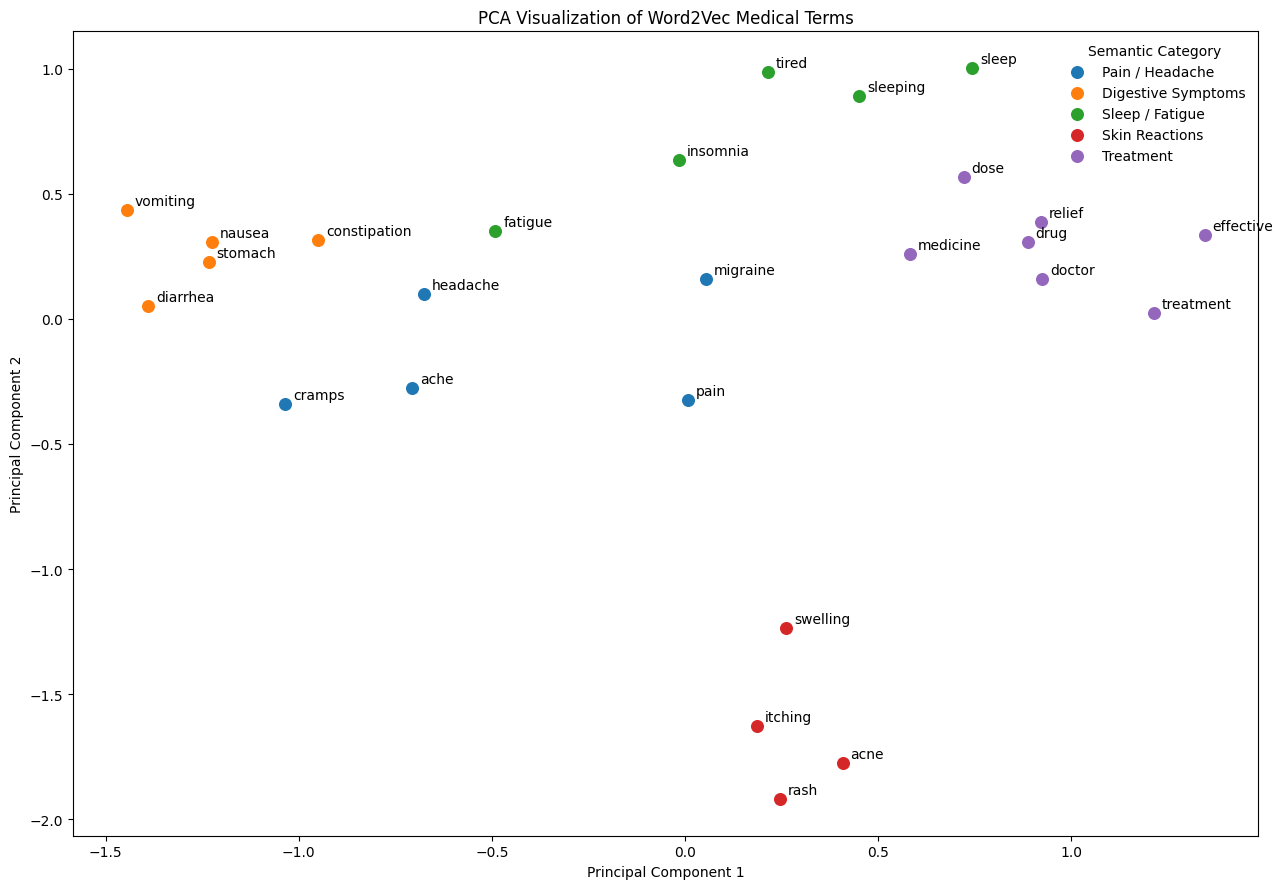

In [ ]:
plt.figure(figsize=(13, 9))

start = 0

for group, group_words in word_groups.items():

    valid_words = [w for w in group_words if w in w2v_model.wv]

    end = start + len(valid_words)

    plt.scatter(
        vectors_pca[start:end, 0],
        vectors_pca[start:end, 1],
        s=70,
        label=group
    )

    for i in range(start, end):
        plt.text(
            vectors_pca[i, 0] + 0.02,
            vectors_pca[i, 1] + 0.02,
            words[i],
            fontsize=10
        )

    start = end

plt.title("PCA Visualization of Word2Vec Medical Terms")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Semantic Category", frameon=False)

plt.tight_layout()
plt.show()

The PCA projection provides a global view of the Word2Vec embedding space by preserving the directions of maximum variance. Although the separation between semantic categories is less pronounced than in the t-SNE visualization, several meaningful groupings are still visible.

For example, digestive symptoms (orange) and skin-related reactions (red) occupy relatively distinct regions of the embedding space, while treatment-related terms (purple) are separated from symptom-related concepts. This indicates that the Word2Vec model successfully captured semantic relationships between medically related words.

Compared with t-SNE, PCA emphasizes the overall structure of the embedding space, whereas t-SNE better preserves local neighborhoods. Together, the two visualizations provide complementary insights into the learned word representations.

# 7. Comparison of Embedding Techniques

TF-IDF and Word2Vec represent two fundamentally different approaches to text feature engineering.

The following table summarizes the main differences observed during this project.

| Aspect                       | TF-IDF                       | Word2Vec                     |
| :--------------------------- | :--------------------------- | :--------------------------- |
| Representation               | Sparse vectors               | Dense vectors                |
| Feature size                 | 5,000 vocabulary terms       | 100-dimensional embeddings   |
| Context awareness            | No                           | Yes                          |
| Captures semantic similarity | No                           | Yes                          |
| Word similarity search       | Not supported                | Supported                    |
| Visualization                | Limited                      | PCA and t-SNE visualizations |
| Best suited for              | Traditional machine learning | Semantic NLP applications    |


The two embedding techniques complement each other rather than compete directly.

TF-IDF provides a simple and efficient numerical representation of text that is highly interpretable and well suited for traditional machine learning models. However, it treats each word independently and therefore cannot capture semantic relationships between words.

Word2Vec addresses this limitation by learning contextual representations from the corpus. The similarity search, together with the PCA and t-SNE visualizations, demonstrated that the model successfully grouped related medical concepts such as symptoms, treatments, and patient experiences. Consequently, Word2Vec provides richer representations for downstream NLP tasks that require semantic understanding.

# 8. Conclusion

In this part of the project, two different approaches for representing text as numerical features were explored. TF-IDF provided a simple and effective statistical representation, while Word2Vec captured semantic relationships between words based on their context. Through the similarity analysis and the PCA and t-SNE visualizations, meaningful connections between medical terms in the drug review dataset were observed. Overall, this comparison provided a better understanding of the strengths of each embedding technique and their suitability for different NLP tasks.

# 9. Save Files and Copy to Shared Data Folder in Google Drive

## 9.1. Save in Colab's Runtime

The cell below will save to a temporary Colab runtime location.

In [ ]:
# Save all outputs to temporary Colab runtime location
sparse.save_npz("tfidf_matrix.npz", tfidf_matrix)
joblib.dump(tfidf, "tfidf_vectorizer.joblib")
w2v_model.save("word2vec_model.model")

## 9.2 Automatically Copy to Google Drive

The cell below will automatically copy all outputs to the shared data folder in Google Drive ensuring that nothing is lost and flowless pipeline execution.

In [ ]:
# Temporary Colab runtime location
COLAB_TMP_DIR = Path("/content")

files = [
    "tfidf_matrix.npz",
    "tfidf_vectorizer.joblib",
    "word2vec_model.model"
]

# Copy feature engineering outputs to shared Drive folder
for file in files:
    source_file = COLAB_TMP_DIR / file
    destination_file = ROOT_DATA_DIR / file

    shutil.copy(source_file, destination_file)
    print(f"Copied: {file}")

print("All files copied successfully.")

Copied: tfidf_matrix.npz
Copied: tfidf_vectorizer.joblib
Copied: word2vec_model.model
All files copied successfully.


The saved files can be reused in future experiments without retraining the embedding models, improving reproducibility and reducing computational cost.